In [8]:
from maskvar.utils.clicker import init_clicks, predict_next_click, to_sam_format
from maskvar.maskseg_build_everything import (
    build_coconut_hf_dataset,
    build_hqseg44k_dataset,
    build_cocolvis_dataset,
)
from maskvar.datasets.mask_level_dataset import (
    MaskLevelFlatDataset
)
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def plot_mask_clicks(gt_mask, dt, click_list, pred_mask=None):
    if pred_mask is None:
        pred_mask = np.zeros_like(gt_mask)
    fig, ax = plt.subplots(1, 4, figsize=(12, 6))
    ax[0].imshow(gt_mask)
    ax[1].imshow(dt)
    ax[2].imshow(pred_mask)
    ax[3].imshow(np.logical_xor(gt_mask > 0, pred_mask > 0))

    pos_clicks = [click for click in click_list if click[2] == 1]
    neg_clicks = [click for click in click_list if click[2] == 0]

    ax[0].scatter([click[1] for click in pos_clicks], [click[0] for click in pos_clicks], color='red', marker='x')
    ax[0].scatter([click[1] for click in neg_clicks], [click[0] for click in neg_clicks], color='blue', marker='x')

    ax[3].scatter([click[1] for click in pos_clicks], [click[0] for click in pos_clicks], color='red', marker='x')
    ax[3].scatter([click[1] for click in neg_clicks], [click[0] for click in neg_clicks], color='blue', marker='x')
    return fig, ax

In [22]:
# dataset = HQSeg44KTrainDataset(data_root='../data/sam-hq')
dataset, _ = build_coconut_hf_dataset('../data/coconut_hf')

masklevel_dataset = MaskLevelFlatDataset(
    index_mapping_path='../data/flat/coconut_hf/train_index_mapping.npy',
    dataset=dataset,
    mask_filter_thresh=0.2,
    with_image_embed=False,
)

Loaded 118200 samples from ../data/coconut_hf/train/
Loaded 5000 samples from ../data/coconut_hf/val/


In [174]:
image, _, single_mask_normalized, single_mask = masklevel_dataset[18]
gt_mask = single_mask.reshape(256, 256).cpu().numpy()

(<Figure size 1200x600 with 4 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object))

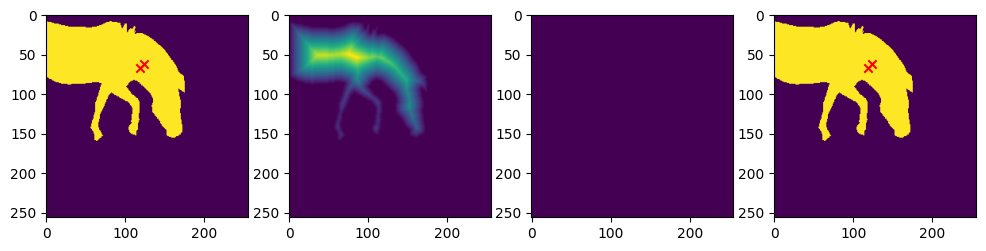

In [175]:
click_list, eroded_mask, dt = init_clicks(gt_mask, num_random_clicks=2)
plot_mask_clicks(gt_mask, dt, click_list)


(<Figure size 1200x600 with 4 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object))

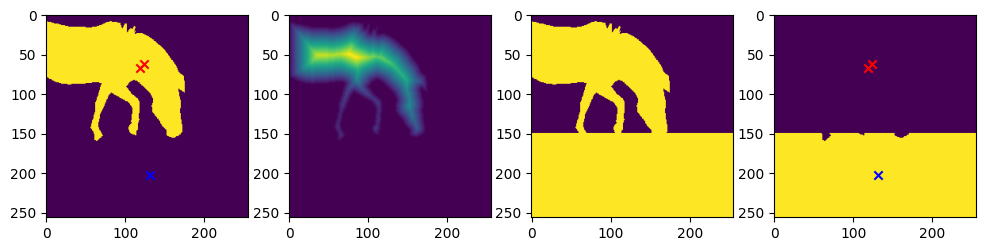

In [176]:
pred_mask = gt_mask.copy()
pred_mask[150:, :] = 1

click, click_list, not_clicked_map = predict_next_click(gt_mask, pred_mask, click_list, not_clicked_map=None)

plot_mask_clicks(gt_mask, dt, click_list, pred_mask)

In [177]:
print(to_sam_format(click_list))
print(to_sam_format(click_list, pad_size=10))

(tensor([[119,  66],
        [124,  62],
        [131, 202]]), tensor([1, 1, 0]))
(tensor([[119.,  66.],
        [124.,  62.],
        [131., 202.],
        [  0.,   0.],
        [  0.,   0.],
        [  0.,   0.],
        [  0.,   0.],
        [  0.,   0.],
        [  0.,   0.],
        [  0.,   0.]]), tensor([ 1,  1,  0, -1, -1, -1, -1, -1, -1, -1], dtype=torch.int32))
